In [ ]:
import numpy as np
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt
import cv2


In [12]:
lena = cv2.imread('C:\Saad\VS Scripts\ipynb\Lab#6\\lena.png', cv2.IMREAD_GRAYSCALE)
cameraman = cv2.imread('C:\Saad\VS Scripts\ipynb\Lab#6\\Standard_Test_Images\cameraman.jpg', cv2.IMREAD_GRAYSCALE)
peppers = cv2.imread('C:\Saad\VS Scripts\ipynb\Lab#6\\Standard_Test_Images\peppers_gray.jpg', cv2.IMREAD_GRAYSCALE)
tom = cv2.imread('C:\Saad\VS Scripts\ipynb\Lab#6\\TC_JR.jpg', cv2.IMREAD_GRAYSCALE)     

images = [lena, cameraman, peppers, tom]
names = ["Lena", "Cameraman", "Peppers", "Tom"]

for img in images:
    if img is None:
        print("One or more images not found.")
        break


<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_12060\3709450797.py:1: SyntaxWarning: invalid escape sequence '\S'
  lena = cv2.imread('C:\Saad\VS Scripts\ipynb\Lab#6\\lena.png', cv2.IMREAD_GRAYSCALE)
C:\Users\Admin\AppData\Local\Temp\ipykernel_12060\3709450797.py:2: SyntaxWarning: invalid escape sequence '\S'
  cameraman = cv2.imread('C:\Saad\VS Scripts\ipynb\Lab#6\\Standard_Test_Images\cameraman.jpg', cv2.IMREAD_GRAYSCALE)
C:\Users\Admin\AppData\Local\Temp\ipykernel_12060\3709450797.py:3: SyntaxWarning: invalid escape sequence '\S'
  peppers = cv2.imread('C:\Saad\VS Scripts\ipynb\Lab#6\\Standard

In [13]:
# Arithmetic Mean
def arithmetic_mean_filter(img, size=3):
    return cv2.blur(img, (size, size))

# Geometric Mean
def geometric_mean_filter(img, size=3):
    img = img.astype(np.float32) + 1
    kernel_size = size
    pad = kernel_size // 2
    result = np.zeros_like(img)
    for i in range(pad, img.shape[0] - pad):
        for j in range(pad, img.shape[1] - pad):
            region = img[i - pad:i + pad + 1, j - pad:j + pad + 1]
            gmean = np.exp(np.mean(np.log(region)))
            result[i, j] = gmean
    return np.uint8(result)

# Harmonic Mean
def harmonic_mean_filter(img, size=3):
    def harmonic_mean(window):
        window = window.flatten()
        window = np.where(window == 0, 1e-5, window)
        return len(window) / np.sum(1.0 / window)
    return generic_filter(img, harmonic_mean, size=(size, size))

# Contraharmonic Mean 
def contraharmonic_mean_filter(img, size=3, Q=1.5):
    img = img.astype(np.float32)
    pad = size // 2
    result = np.zeros_like(img)
    for i in range(pad, img.shape[0]-pad):
        for j in range(pad, img.shape[1]-pad):
            region = img[i-pad:i+pad+1, j-pad:j+pad+1]
            num = np.sum(np.power(region, Q + 1))
            den = np.sum(np.power(region, Q))
            result[i, j] = num / (den + 1e-5)
    return np.uint8(np.clip(result, 0, 255))

# Median 
def median_filter(img, size=3):
    return cv2.medianBlur(img, size)

# Max 
def max_filter(img, size=3):
    return cv2.dilate(img, np.ones((size, size), np.uint8))

# Min 
def min_filter(img, size=3):
    return cv2.erode(img, np.ones((size, size), np.uint8))

# Laplacian 
def laplacian_filter(img):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = cv2.convertScaleAbs(lap)
    return lap

In [14]:
def show_images(img_list, title_list, cmap='gray'):
    n = len(img_list)
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(img_list[i], cmap=cmap)
        plt.title(title_list[i])
        plt.axis('off')
    plt.show()

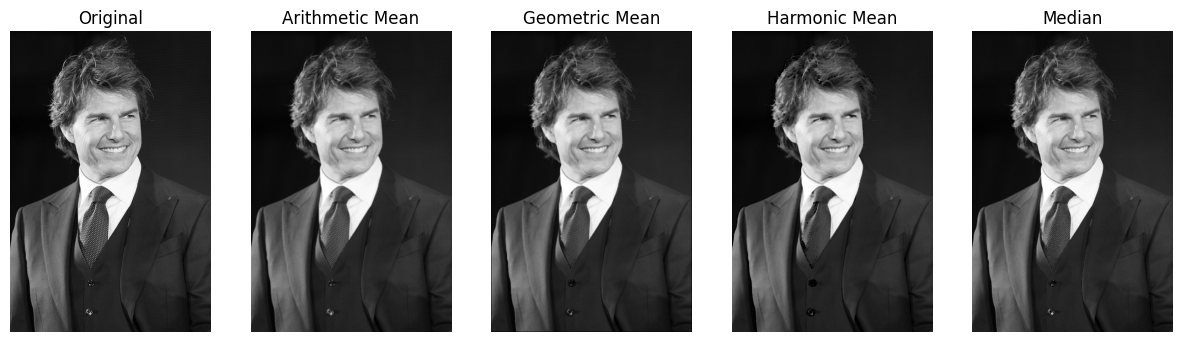

In [15]:

# 5.1 Smoothing Filter to Image
test_img = tom

arith = arithmetic_mean_filter(test_img)
geo = geometric_mean_filter(test_img)
harm = harmonic_mean_filter(test_img)
med = median_filter(test_img)

show_images([test_img, arith, geo, harm, med],
            ["Original", "Arithmetic Mean", "Geometric Mean", "Harmonic Mean", "Median"])


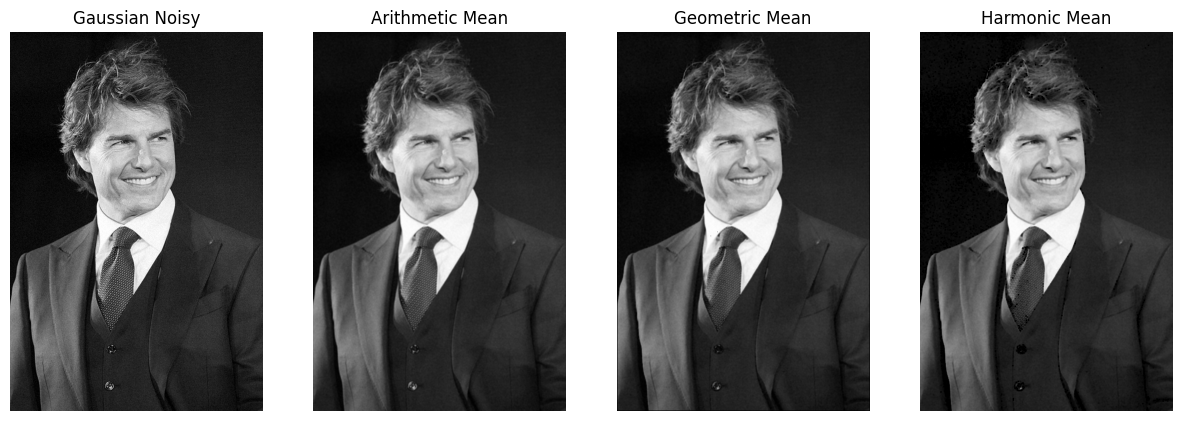

In [16]:
# 5.2 Add Gaussian Noise and Apply Filters
def add_gaussian_noise(img, mean=0, var=30):
    noise = np.random.normal(mean, var ** 0.5, img.shape)
    noisy = img + noise
    return np.uint8(np.clip(noisy, 0, 255))

noisy_gaussian = add_gaussian_noise(test_img)

arith = arithmetic_mean_filter(noisy_gaussian)
geo = geometric_mean_filter(noisy_gaussian)
harm = harmonic_mean_filter(noisy_gaussian)

show_images([noisy_gaussian, arith, geo, harm],
            ["Gaussian Noisy", "Arithmetic Mean", "Geometric Mean", "Harmonic Mean"])


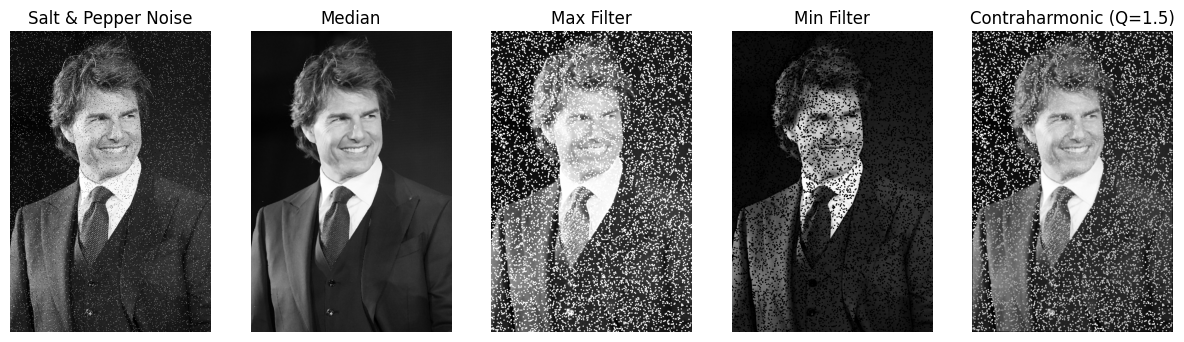

In [17]:
# 5.3 Add Salt-and-Pepper Noise and Apply Filters
def add_salt_pepper_noise(img, prob=0.05):
    noisy = np.copy(img)
    salt = np.random.rand(*img.shape) < prob / 2
    pepper = np.random.rand(*img.shape) < prob / 2
    noisy[salt] = 255
    noisy[pepper] = 0
    return noisy

noisy_sp = add_salt_pepper_noise(test_img)

med = median_filter(noisy_sp)
maxf = max_filter(noisy_sp)
minf = min_filter(noisy_sp)
contra = contraharmonic_mean_filter(noisy_sp, Q=1.5)

show_images([noisy_sp, med, maxf, minf, contra],
            ["Salt & Pepper Noise", "Median", "Max Filter", "Min Filter", "Contraharmonic (Q=1.5)"])


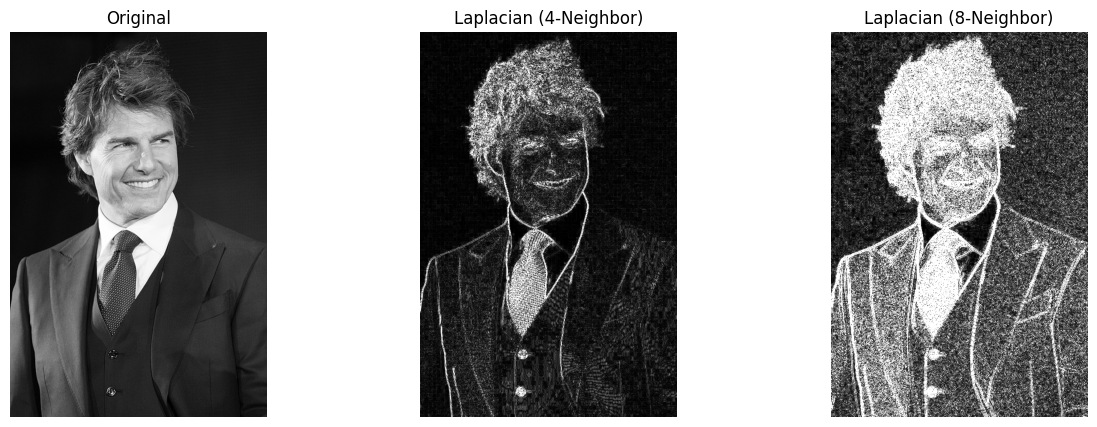

In [ ]:
# 5.4 Laplacian Filters
lap4 = cv2.Laplacian(test_img, cv2.CV_64F, ksize=3)
lap4 = cv2.convertScaleAbs(lap4)

lap8 = cv2.Laplacian(test_img, cv2.CV_64F, ksize=5)
lap8 = cv2.convertScaleAbs(lap8)

show_images([test_img, lap4, lap8], ["Original", "Laplacian (4-Neighbor)", "Laplacian (8-Neighbor)"])


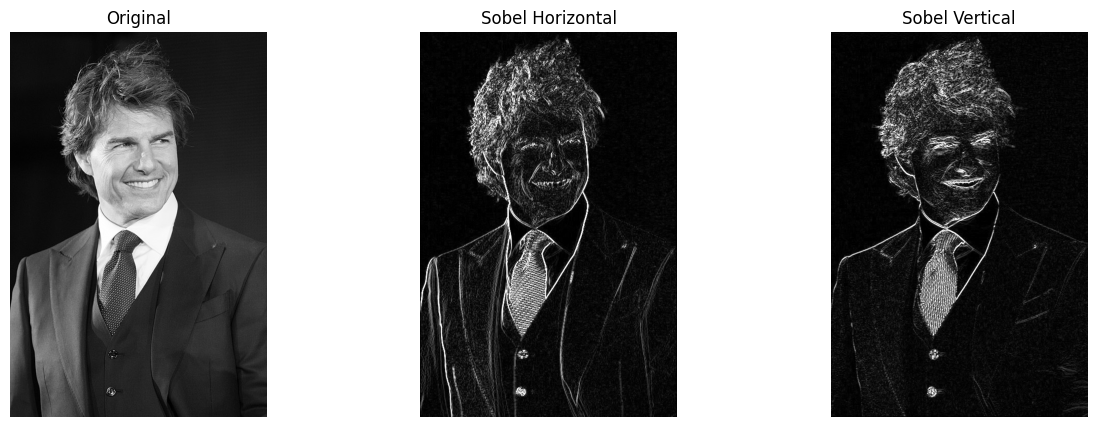

In [19]:
# 5.5 Sobel Edge Detection
sobelx = cv2.Sobel(test_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(test_img, cv2.CV_64F, 0, 1, ksize=3)

sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.convertScaleAbs(sobely)

show_images([test_img, sobelx, sobely],
            ["Original", "Sobel Horizontal", "Sobel Vertical"])


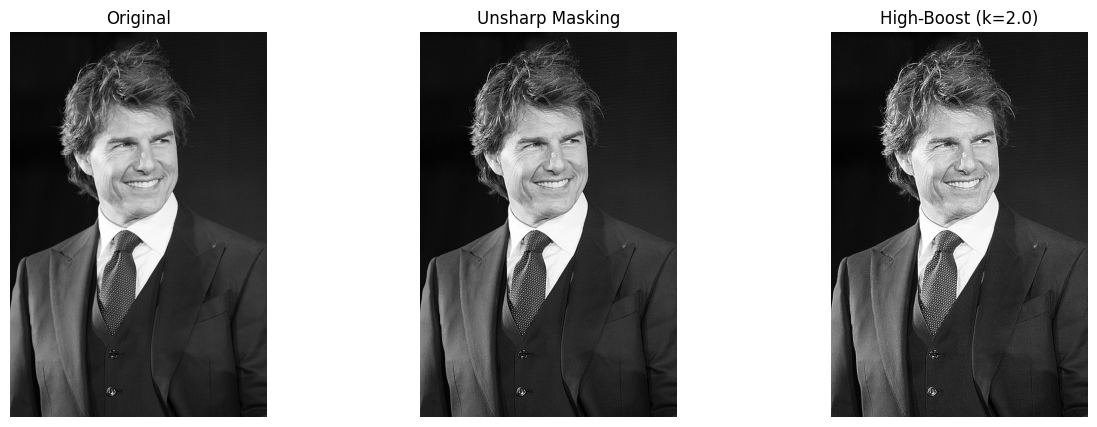

In [20]:
# 5.6 Unsharp Masking and High-Boost Filtering
blurred = cv2.GaussianBlur(test_img, (5, 5), 0)
unsharp = cv2.addWeighted(test_img, 1.5, blurred, -0.5, 0)

# High-Boost Filtering
k = 2.0  
mask = cv2.subtract(test_img, blurred)
high_boost = cv2.add(test_img, cv2.multiply(mask, k))

show_images([test_img, unsharp, high_boost],
            ["Original", "Unsharp Masking", f"High-Boost (k={k})"])
